# Photonic Hopfield
### This scripts provide some useful function to characterize a given scattering matrix S in the framework of a interferometric experiment as it has been described in [Multiphoton Quantum Simulation of the Generalized Hopfield Memory Model](https://https://journals.aps.org/prl/pdf/10.1103/945c-11wt). Example of usage are provided in the script.
## Standard function for generating matrix and building permanents, the *gauge_unfixing* function is needed to unbias the result of *numpy* bultin function *np.linalg.eig*.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def generate_random_haar(n: int, rng = np.random.default_rng()):

    """
    This function generates an nxn random Haar
    matrix according to the article by Mezzadri. (QR decomposition)
    """

    Z = (rng.normal(size=(n, n)) + 1j * rng.normal(size=(n, n))) / np.sqrt(2.0) # random initializing
    Q, R = np.linalg.qr(Z) # QR decomposition step
    d = np.diag(R)
    ph = d / np.abs(d)
    Q = Q * np.conj(ph)

    return Q

def gauge_unfixing(vector):
  """
  In general when you perform a linalg algorithm function there's some bias on the eigvec phase,
  this should manage the issue by defining a random phase for each vector

  """
  ɸ = np.random.uniform(0, 2*np.pi)
  return vector * np.exp(1j * ɸ)

"""def optimal_gauge(v):
    # rotate the phase to maximize the eigval real part
    ɸ = np.angle(np.dot(v, np.conj(v))) 
    return v * np.exp(-1j * ɸ / 2)"""


def build_perm(Sk1, Sk2):
  """Build permanent form"""
  return np.outer(Sk1, Sk2) + np.outer(Sk1, Sk2)

### Function to upload your S matrix 

### Function to upload your S matrix 

In [290]:
import os
import numpy as np

def load_S_matrix(file_path: str, *, npz_key: str | None = None, delimiter: str = ",") -> np.ndarray:
    """Load the scattering matrix S from disk.

    Supported formats (auto-detected by extension):
      - .npy : NumPy binary array (recommended)
      - .npz : NumPy archive (use npz_key or defaults to 'S' / first array)
      - .csv/.txt/.dat : text matrix (real or complex; accepts entries like '0.3+0.2j' or '0.3+0.2i')

    Returns
    -------
    S : np.ndarray (complex dtype when needed)
    """
    if not isinstance(file_path, str) or not file_path:
        raise ValueError("file_path must be a non-empty string")

    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".npy":
        S = np.load(file_path)

    elif ext == ".npz":
        data = np.load(file_path)
        key = npz_key
        if key is None:
            key = "S" if "S" in data.files else (data.files[0] if data.files else None)
        if key is None:
            raise ValueError("Empty .npz archive: no arrays found")
        if key not in data.files:
            raise KeyError(f"Key '{key}' not found in .npz. Available keys: {data.files}")
        S = data[key]

    elif ext in {".csv", ".txt", ".dat"}:
        # First attempt: direct complex parsing (works if entries contain 'j')
        try:
            S = np.genfromtxt(file_path, delimiter=delimiter, dtype=complex)
        except Exception:
            # Fallback: load as strings and parse (also supports 'i' for imaginary unit)
            raw = np.genfromtxt(file_path, delimiter=delimiter, dtype=str)
            if raw.ndim == 1:
                raw = raw.reshape(1, -1)
            def _to_complex(x: str) -> complex:
                x = x.strip().replace("i", "j").replace("I", "j")
                return complex(x)
            S = np.vectorize(_to_complex, otypes=[complex])(raw)

    else:
        raise ValueError(f"Unsupported extension '{ext}'. Use .npy, .npz, .csv, .txt, or .dat")

    S = np.asarray(S)
    if S.ndim != 2 or S.shape[0] != S.shape[1]:
        raise ValueError(f"S must be a square 2D matrix; got shape {S.shape}")
    return S


In [291]:
# Esxample of loading
S_load = load_S_matrix("S.csv")
print(S_load)

[[-0.01247049-0.36663759j -0.25986832-0.16733732j -0.28230875+0.05347841j
   0.32838907-0.10932092j -0.02270627-0.01670549j -0.41539307+0.00793925j
  -0.21057516-0.24556814j  0.45933074-0.11990639j  0.13367456+0.12611434j
   0.14940426-0.08959421j]
 [ 0.32046202+0.09045069j -0.1580237 -0.11404052j  0.09399475+0.32952298j
   0.10534868-0.38154129j -0.17080494-0.35594355j -0.06907725+0.24023954j
   0.43272862+0.09596243j -0.01134345+0.09531613j  0.09693951+0.18347838j
  -0.04079975+0.32908022j]
 [-0.10093852+0.16835309j  0.25821919-0.03728778j -0.18927722-0.16102691j
  -0.20605195-0.11329676j -0.17109329+0.07547665j -0.25454873-0.20222256j
  -0.22338147+0.03451243j -0.11543214-0.25794658j  0.1978591 +0.12006378j
   0.16878219+0.65014691j]
 [-0.27281481+0.18267185j -0.02060561+0.27572661j  0.00712716-0.01781215j
  -0.06720627-0.21268419j  0.32140202-0.35403628j -0.25937711-0.22089207j
   0.25889377-0.24114084j  0.08421978+0.04431208j -0.18932996-0.41095096j
   0.28538893+0.02277001j]
 [-0

## This function aligns the sign of the real and imaginary part of the eigenvector with the maximum eigenvalue

In [340]:
def align_sigma_vector(eigvals, eigvecs):
    """
    This function aligns an array of +-1 value (our phases) to the sign of
    the real (and imaginary) part of the maximum eigenvalue eigenvector.

    Args:
        eigvals (np.ndarray): eigenvalues array.
        eigvecs (np.ndarray): eigenvectors array.

    Returns:
        np.ndarray: aligned phases vector (+1 o -1) for real alignment.
        np.ndarray: aligned phases vector (+1 o -1) for imaginary alignment
        np.ndarray: selected maximum eigvec
        complex: max eigval.
    """
    # find the index relative to the maximal eigvalue in modulus
    selected_idx = np.argmax(np.sqrt(eigvals.real**2+eigvals.imag**2))

    selected_eigenvalue = eigvals[selected_idx]
    selected_eigenvector = eigvecs[:, selected_idx]
    #selected_eigenvector = optimal_gauge(eigvecs[:, selected_idx])

    selected_eigenvector = gauge_unfixing(eigvecs[:, selected_idx]) # phase freedom randomized

    # extract the alignment part
    target_part = selected_eigenvector.real

    # create the sigma vector (phases)
    sigma_r = np.where(target_part >= 0, 1, -1)

    target_part = selected_eigenvector.imag

    # create the sigma vector (phases)
    sigma_i = np.where(target_part >= 0, 1, -1)

    return sigma_r, sigma_i, selected_eigenvector, selected_eigenvalue


The overlap is defined as:
$$\mathbb M^{(k_1,k_2)} = \left(1-\delta_{k_1,k_2}\right) \left[\sqrt{2}\,  m_{k_1} m_{k_2}\right]+ \delta_{k_1,k_2} \left[
\left(m^{(k_1)}\right)^2 
\right]$$
where $$m^{(k)} \equiv \frac{1}{\sqrt{M}}\sum_{x=1}^M S_{k,x}\, \sigma_x \quad ; \quad \max_{M\gg 1} m^{(k)}=O(1)$$

In [341]:
def run_experiment(S, k1, k2):
    """
    This function is an experiment run:
    fixing a scattering matrix and the two measuring modes k1 and k2
    you get the max eigvec and eigval, the best sigmas i.e. the one
    aligned respectively to the real and the imaginary part, and the
    corresponding overlap considering the two configurations
    """
    Sk1 = S[k1,:]
    Sk2 = S[k2,:]
    M = np.size(Sk1) # mode number
    𝕏 = build_perm(Sk1, Sk2)
    eigvals_perm, eigvecs_perm = np.linalg.eig(𝕏) # linearizes the matrix

    threshold = 1e-14
    rounded_eigvals_perm = np.copy(eigvals_perm)

    # Set tiny imaginary parts to zero
    rounded_eigvals_perm.imag[np.abs(rounded_eigvals_perm.imag) < threshold] = 0.0

    # Set tiny real parts to zero
    rounded_eigvals_perm.real[np.abs(rounded_eigvals_perm.real) < threshold] = 0.0

    # compute best sigmas choosing both real and imaginary alignment

    sigma_real, sigma_imaginary, selected_eigenvector, selected_eigenvalue = align_sigma_vector(eigvals_perm, eigvecs_perm)

    if (k1 != k2):

        𝕄_real = (np.sqrt(2)/M)*np.dot(Sk1, sigma_real)*np.dot(Sk2, sigma_real) #+ ((2-np.sqrt(2))/M) * np.dot(Sk2, Sk1)

        𝕄_imaginary = (np.sqrt(2)/M)*np.dot(Sk1, sigma_imaginary)*np.dot(Sk2, sigma_imaginary) #+ ((2-np.sqrt(2))/M) * np.dot(Sk2, Sk1)

        #𝕄_real = (2*np.sqrt(2)/np.sqrt(M*(M+1)))*np.dot(Sk1, sigma_real)*np.dot(Sk2, sigma_real)

        #𝕄_imaginary = (2*np.sqrt(2)/np.sqrt(M*(M+1)))*np.dot(Sk1, sigma_imaginary)*np.dot(Sk2, sigma_imaginary)

    else: # bunched configuration

        𝕄_real = (1/M)*np.dot(Sk1, sigma_real)**2 #+ ((np.sqrt(2)-1)/M) * np.dot(Sk2, Sk1)

        𝕄_imaginary = (1/M)*np.dot(Sk1, sigma_imaginary)**2 #+ ((np.sqrt(2)-1)/M) * np.dot(Sk2, Sk1)

        #𝕄_real = (2/np.sqrt(M*(M+1)))*np.dot(Sk1, sigma_real)**2 - (2 - np.sqrt(2))/np.sqrt(M*(M+1))

        #𝕄_imaginary = (2/np.sqrt(M*(M+1)))*np.dot(Sk1, sigma_imaginary)**2 - (2 - np.sqrt(2))/np.sqrt(M*(M+1))


    return sigma_real, sigma_imaginary, 𝕄_real, 𝕄_imaginary, selected_eigenvector, selected_eigenvalue






## Note
### 𝕄_real and 𝕄_imaginary are not the real and imaginary part of 𝕄, but on the contrary the complex value of 𝕄 with the two different alignment framework

In [342]:
# use example

n = 10

S = generate_random_haar(n)

k1 = 0
k2 = 1
sigma_real, sigma_imaginary, 𝕄_real, 𝕄_imaginary, selected_eigenvector, selected_eigenvalue = run_experiment(S, k1, k2)
# print(S)

In [343]:
print(sigma_real, sigma_imaginary, 𝕄_real, 𝕄_imaginary, selected_eigenvalue)
print("")
print(selected_eigenvector)

[-1 -1  1 -1 -1  1 -1  1 -1  1] [-1 -1  1 -1 -1 -1  1  1  1  1] (-0.4049973081141227+0.26179662398208686j) (-0.08547700135341291+0.20723711437112563j) (-0.3180994388501623+0.6466583471737233j)

[-0.20684576-0.24130823j -0.2434763 -0.09155965j  0.02444054+0.11057266j
 -0.23974063-0.09087916j -0.22196166-0.32567133j  0.03788462-0.20399202j
 -0.40357174+0.28198739j  0.24253916+0.41232506j -0.14749849+0.02173322j
  0.04352875+0.24297972j]


In [344]:
def check_unitary(S):
    """
    Return a Bool True/False if the matrix is unitary or not

    """
    out = True # initial assumption
    tol = 10**(-14) # error tolerance
    for i in range(len(S)):
        count = 0
        for j in range(len(S)):
            count += np.dot(np.conjugate(S[i,j]), S[i,j])
        if count > 1+tol or count < 1-tol:
            out = False
    return out


In [345]:
# hand construction of a matrix which is not unitary
S = np.zeros((n, n), dtype=complex)
# print(S.shape)

# filling the matrix wrongfully

for i in range(n):
    for r in range(n):
        S[i, r] = np.random.randn() + 1j*np.random.randn()# this is not unitary but a complex number

check_unitary(S)

False

In [346]:
n = 10
# true random haar matrix
S = generate_random_haar(n)
check_unitary(S)

True

## Now the idea is to run an experiment measuring all possible combinations of pairs detectors. You can decide if you want to exclude bunched configurations by the bool *exclude_bunched* var False or True valued. The *run_all_alignment* function will give all the variables connected to all this configurations. Then *find_best_alignment* will give you the best k pair (the one that maximizes the modulus of $\mathbb{M}$) and the setting for the sigma, and the corresponding eigvec and eigval.

In [347]:
def run_all_alignment(S, exclude_bunched, do_a_print):
    # exclude_bunched isbool var to exclude bunched
    # config and to put or not to put a norm factor
    if not check_unitary(S):
        raise ValueError("Input matrix is not unitary!")

    # Initialize the storage
    results = {
        "sigma_r": [], "sigma_i": [],
        "M_r": [], "M_i": [],
        "e_vec": [], "e_val": [],
        "k_pairs": []
    }

    n = len(S)
    max_val_sq = -1.0
    best_k = (0, 0)

    for k1 in range(n):
        for k2 in range(n):
            # if exclude_bunched is true and we are on diagonal jump
            if exclude_bunched and (k1 == k2):
                continue
            if k1> k2:
               continue # sum only lower diag
            # run experiment
            s_r, s_i, m_r, m_i, e_vec, e_val = run_experiment(S, k1, k2)

            # norm computation
            m_r_sq = abs(m_r)**2
            m_i_sq = abs(m_i)**2
            # save data
            results["sigma_r"].append(s_r)
            results["sigma_i"].append(s_i)
            results["M_r"].append(m_r_sq)
            results["M_i"].append(m_i_sq)
            results["e_vec"].append(e_vec)
            results["e_val"].append(e_val)
            results["k_pairs"].append((k1, k2))

            # find the max
            current_max_sq = max(m_r_sq, m_i_sq)

            if current_max_sq > max_val_sq:
                max_val_sq = current_max_sq
                best_k = (k1, k2)
                # choose the right norm
    final_max_modulus = max_val_sq
    if do_a_print:
      print(f"--- Experiment Complete ---")
      print(f"Best couple (k1, k2): {best_k} with Max Modulus : {final_max_modulus:.6f}")

    return results, best_k,

In [348]:
def find_best_alignment(S, exclude_bunched, do_a_print):

  """
  Given the results of all perms run of function run_alignment this
  function output the sigma_r sigma_i, M_r, M_i, e_vec, e_val maximal
  given a certain matrix S and the exclude_bunched setting
  """
  results, best_k = run_all_alignment(S, exclude_bunched, do_a_print)
  idx = results["k_pairs"].index(best_k)

  sigma_r = results["sigma_r"][idx]
  sigma_i = results["sigma_i"][idx]
  M_r = results["M_r"][idx]
  M_i = results["M_i"][idx]
  e_vec = results["e_vec"][idx]
  e_val = results["e_val"][idx]
  return sigma_r, sigma_i, M_r, M_i, e_vec, e_val, best_k

In [349]:
def check_norm(n, best_sigma_r, S):
  mki = 0
  mki_2 = 0
  mki_2_2 = 0
  M_abs_sq = 0
  out = 0
  mki_2 = 0
  M = np.zeros((n,n), dtype=complex)

  for i in range(n):
    mki = np.dot(S[i,:], best_sigma_r)/np.sqrt(n)
    mki_2 += np.abs(mki)**2

    for j in range(n):
      Sk1 = S[i,:]
      Sk2 = S[j,:]
      if i == j:
        M[i,j] = (1/n)*(np.dot(Sk1, best_sigma_r))**2  # + ((np.sqrt(2)-1)/n) * np.dot(Sk2, Sk1)
        # M[i,j] = (1/np.sqrt(n*(n+1)))*np.dot(Sk1, best_sigma_r)**2 + ((np.sqrt(2)-1)/np.sqrt(n*(n+1))) * np.dot(Sk2, Sk1)
      elif i<j:
        # M[i,j] = 2*np.sqrt(2)*np.dot(S[i,:], best_sigma_r)*np.dot(S[j,:], best_sigma_r)/(n) + np.dot(Sk2, Sk1)*(2-np.sqrt(2))/n
        M[i,j] = (np.sqrt(2)/n)*np.dot(Sk1, best_sigma_r)*np.dot(Sk2, best_sigma_r) #+ ((2-np.sqrt(2))/np.sqrt(n*(n+1))) * np.dot(Sk2, Sk1)

  mki_2_2 += mki_2**2
  M_abs_sq += abs(M)**2
  out += np.sum(M_abs_sq)

  return out, M_abs_sq, mki_2_2


## Binary Case


In [350]:
S_bin = 1/2 * np.array([
    [1,  1,  1,  1],
    [1, -1, -1,  1],
    [1,  1, -1, -1],
    [1, -1, -1,  1]
],dtype=complex)

In [351]:
from itertools import product

def binary_overlap_finder(S_bin, k1, k2):
    u = S_bin[k1, :]
    v = S_bin[k2, :]
    M = len(u)

    best_vectors = []
    best_value = -np.inf

    for x_tuple in product([-1, 1], repeat=4):
        x = np.array(x_tuple)
        du = np.dot(u, x)
        dv = np.dot(v, x)
        val = du * dv
        
        print(f"x = {x}, u·x = {np.real(du)}, v·x = {np.real(dv)}, prodotto = {np.real(val)}")
        
        if val > best_value:
            best_value = val
            best_vectors = [x.copy()]
        elif val == best_value:
            best_vectors.append(x.copy())

    if k1==k2:
        factor = (1/M)
    else:
        factor = (np.sqrt(2)/M)

    print("\nMassimo valore:", np.real(factor*best_value))
    print(f"vettore S[{k1},:]:   (1/{np.sqrt(M)}) {np.real(np.sqrt(M)*u)}")
    print(f"vettore S[{k2},:]:   (1/{np.sqrt(M)}) {np.real(np.sqrt(M)*v)}")
    print("Vettori che lo realizzano:")
    for x in best_vectors:
        print(x)

In [352]:

k1 = 0
k2 = 1

binary_overlap_finder(S_bin, k1, k2)

x = [-1 -1 -1 -1], u·x = -2.0, v·x = 0.0, prodotto = -0.0
x = [-1 -1 -1  1], u·x = -1.0, v·x = 1.0, prodotto = -1.0
x = [-1 -1  1 -1], u·x = -1.0, v·x = -1.0, prodotto = 1.0
x = [-1 -1  1  1], u·x = 0.0, v·x = 0.0, prodotto = 0.0
x = [-1  1 -1 -1], u·x = -1.0, v·x = -1.0, prodotto = 1.0
x = [-1  1 -1  1], u·x = 0.0, v·x = 0.0, prodotto = 0.0
x = [-1  1  1 -1], u·x = 0.0, v·x = -2.0, prodotto = -0.0
x = [-1  1  1  1], u·x = 1.0, v·x = -1.0, prodotto = -1.0
x = [ 1 -1 -1 -1], u·x = -1.0, v·x = 1.0, prodotto = -1.0
x = [ 1 -1 -1  1], u·x = 0.0, v·x = 2.0, prodotto = 0.0
x = [ 1 -1  1 -1], u·x = 0.0, v·x = 0.0, prodotto = 0.0
x = [ 1 -1  1  1], u·x = 1.0, v·x = 1.0, prodotto = 1.0
x = [ 1  1 -1 -1], u·x = 0.0, v·x = 0.0, prodotto = 0.0
x = [ 1  1 -1  1], u·x = 1.0, v·x = 1.0, prodotto = 1.0
x = [ 1  1  1 -1], u·x = 1.0, v·x = -1.0, prodotto = -1.0
x = [1 1 1 1], u·x = 2.0, v·x = 0.0, prodotto = 0.0

Massimo valore: 0.3535533905932738
vettore S[0,:]:   (1/2.0) [1. 1. 1. 1.]
vettore S[1,:]: 

## Ideal Workflow

In [353]:
# this is for the programmer to produce a csv file to test in order for you to have
# your S matrix upload it in csv format

S = generate_random_haar(10)
np.savetxt("S.csv", S.astype(str), delimiter=",", fmt="%s")

### 1) Upload your S matrix

In [354]:
S = load_S_matrix("S.csv")
n = len(S[0])
print(f"The matrix dimension is: {n} x {n}.")


The matrix dimension is: 10 x 10.


### 2) Find the best alignment vector

In [355]:
exclude_bunched = False # set it true if you want to look at non bunched config
do_a_print = True

sigma_r, sigma_i, M_r, M_i, e_vec, e_val, best_k = find_best_alignment(S, exclude_bunched, do_a_print)

--- Experiment Complete ---
Best couple (k1, k2): (9, 9) with Max Modulus : 0.256764


In [356]:
print(e_val)

(0.9309432663178077-0.056898707846636025j)


### 3)  Check the normalization

In [357]:
M_norm, M_abs_sq, m_norm = check_norm(n, sigma_r, S)
print(f"$\sum_k |𝕄|^2: {M_norm}")
print(f"(\sum_k |m_k|^2)^2: {m_norm}")

$\sum_k |𝕄|^2: 0.9999999999999996
(\sum_k |m_k|^2)^2: 0.9999999999999996


In [358]:
n_samp = 100
M = 10
exclude_bunched = False
do_a_print = False

M_norm_l = []
m_norm_l = []

for k in range(n_samp):
    S = generate_random_haar(M)
    sigma_r, sigma_i, M_r, M_i, e_vec, e_val, best_k = find_best_alignment(
        S, exclude_bunched, do_a_print
    )
    M_norm, M_abs_sq, m_norm = check_norm(M, sigma_r, S)  # <-- M, non n

    M_norm_l.append(M_norm)
    m_norm_l.append(m_norm)

mean_M_norm = np.mean(M_norm_l)
mean_m_norm = np.mean(m_norm_l)

print(mean_M_norm, 1 + 1/M)
print(mean_m_norm)

1.0 1.1
1.0


In [359]:
M_norm_f = []
n_samp = 1
M_max = 50
for j in range(M_max):              # M = 1..10
    M = j + 1
    M_norm_l = []
    m_norm_l = []

    for k in range(n_samp):
        S = generate_random_haar(M)
        sigma_r, sigma_i, M_r, M_i, e_vec, e_val, best_k = find_best_alignment(
            S, exclude_bunched, do_a_print
        )
        M_norm, M_abs_sq, m_norm = check_norm(M, sigma_r, S)

        M_norm_l.append(M_norm)
        m_norm_l.append(m_norm)

    mean_M_norm = np.mean(M_norm_l)
    mean_m_norm = np.mean(m_norm_l)
    M_norm_f.append(mean_M_norm)

    print(M, mean_M_norm, 1 + 1/M, mean_m_norm)

1 0.9999999999999996 2.0 0.9999999999999991
2 0.9999999999999996 1.5 0.9999999999999996
3 1.0 1.3333333333333333 1.0
4 0.9999999999999998 1.25 0.9999999999999996
5 0.9999999999999998 1.2 0.9999999999999998
6 1.0 1.1666666666666667 1.0000000000000009
7 0.9999999999999998 1.1428571428571428 0.9999999999999996
8 0.9999999999999996 1.125 0.9999999999999991
9 1.0000000000000004 1.1111111111111112 0.9999999999999998
10 0.9999999999999996 1.1 0.9999999999999998
11 0.9999999999999997 1.0909090909090908 0.9999999999999996
12 0.9999999999999999 1.0833333333333333 1.0
13 1.0 1.0769230769230769 1.0000000000000004
14 1.0000000000000004 1.0714285714285714 1.0000000000000009
15 0.9999999999999998 1.0666666666666667 0.9999999999999991
16 0.9999999999999999 1.0625 1.0
17 0.9999999999999997 1.0588235294117647 0.9999999999999991
18 1.0000000000000004 1.0555555555555556 1.0000000000000009
19 0.9999999999999997 1.0526315789473684 0.9999999999999991
20 0.9999999999999994 1.05 0.9999999999999996
21 1.0 1.047

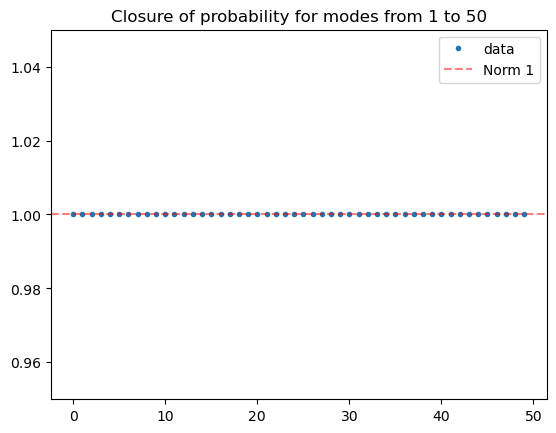

In [360]:
x = np.arange(1, M_max+1)
y = 1 + 1/x

M_norm_f_arr = np.asarray(M_norm_f)
if M_norm_f_arr.shape[0] != x.shape[0]:
    raise ValueError(f"Shape mismatch: len(x)={len(x)} vs len(M_norm_f)={len(M_norm_f_arr)}")

plt.figure()
plt.plot(M_norm_f_arr, "o", label="data", markersize=3)

#plt.plot(x, y, "-", label="Theo")
plt.title("Closure of probability for modes from 1 to 50")
plt.axhline(1.0, label="Norm 1", linestyle="--", color="red", alpha = 0.5)
plt.ylim(0.95,1.05)
plt.legend()
plt.show()

### 4) Visualize the distribution of all the possible |𝕄|^2 with real and imaginary alignment

In [381]:
S = generate_random_haar(10)

results, best_k = run_all_alignment(S, exclude_bunched, do_a_print)

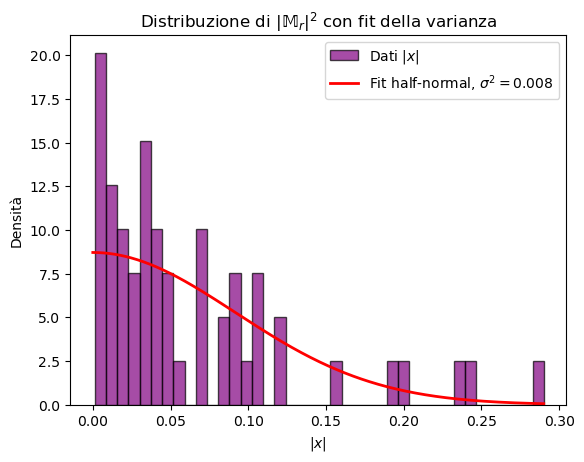

sigma_hat = 0.091578
var_hat   = 0.008387


In [382]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import halfnorm

# esempio: prendo x come una normale centrata
# sostituisci questa riga con i tuoi dati se li hai già
x = abs(np.array(results["M_i"]))

# fit della varianza di x assumendo media nulla
sigma_hat = np.sqrt(np.mean(x**2))
var_hat = sigma_hat**2

# istogramma normalizzato
plt.hist(x, bins=40, density=True, alpha=0.7,
         color='purple', edgecolor='black', label=r'Dati $|x|$')

# pdf fitted half-normal
xx = np.linspace(0, x.max(), 500)
pdf_fit = halfnorm(scale=sigma_hat).pdf(xx)
plt.plot(xx, pdf_fit, 'r-', lw=2,
         label=rf'Fit half-normal, $\sigma^2={var_hat:.3f}$')

plt.title(r'Distribuzione di $|𝕄_r|^2$ con fit della varianza')
plt.xlabel(r'$|x|$')
plt.ylabel('Densità')
plt.legend()
plt.show()

print(f"sigma_hat = {sigma_hat:.6f}")
print(f"var_hat   = {var_hat:.6f}")

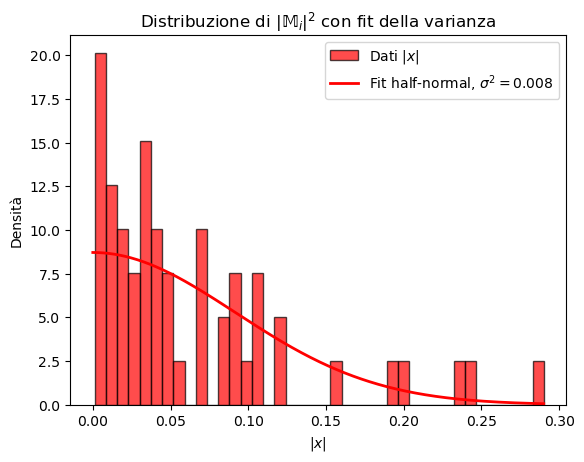

sigma_hat = 0.091578
var_hat   = 0.008387


In [383]:

import matplotlib.pyplot as plt
from scipy.stats import halfnorm

# esempio: prendo x come una normale centrata
# sostituisci questa riga con i tuoi dati se li hai già
x = abs(np.array(results["M_i"]))

# fit della varianza di x assumendo media nulla
sigma_hat = np.sqrt(np.mean(x**2))
var_hat = sigma_hat**2

# istogramma normalizzato
plt.hist(x, bins=40, density=True, alpha=0.7,
         color='red', edgecolor='black', label=r'Dati $|x|$')

# pdf fitted half-normal
xx = np.linspace(0, x.max(), 500)
pdf_fit = halfnorm(scale=sigma_hat).pdf(xx)
plt.plot(xx, pdf_fit, 'r-', lw=2,
         label=rf'Fit half-normal, $\sigma^2={var_hat:.3f}$')

plt.title(r'Distribuzione di $|𝕄_i|^2$ con fit della varianza')
plt.xlabel(r'$|x|$')
plt.ylabel('Densità')
plt.legend()
plt.show()

print(f"sigma_hat = {sigma_hat:.6f}")
print(f"var_hat   = {var_hat:.6f}")

In [338]:
S = generate_random_haar(10)
sigma_r, sigma_i, M_r, M_i, e_vec, e_val, best_k = find_best_alignment(S, True, do_a_print)
k1, k2 = best_k
_,_,all_M = find_best_sigma_with_enumeration(S, k1, k2)
sigma_real, sigma_imaginary, 𝕄_real, 𝕄_imaginary, selected_eigenvector, selected_eigenvalue = run_experiment(S, k1, k2)



Massimo valore: 0.17374452601188456
Vettori che lo realizzano:
[-1.  1. -1.  1. -1. -1.  1.  1.  1. -1.]
[ 1. -1.  1. -1.  1.  1. -1. -1. -1.  1.]


In [339]:
print(sigma_real, sigma_imaginary)
print(np.abs(𝕄_real)**2, np.abs(𝕄_imaginary)**2)

[ 1 -1 -1 -1  1  1 -1 -1 -1  1] [-1  1 -1  1 -1 -1  1  1  1 -1]
0.08928148861299713 0.17374452601188456


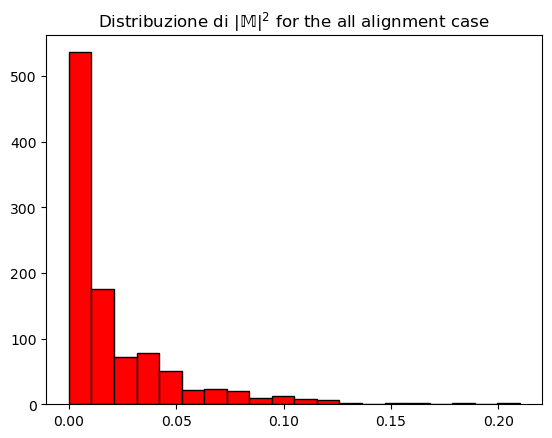

In [255]:
# Calcolo del modulo quadro totale

plt.hist(all_M, bins=20, color='red', edgecolor='black')
plt.title(r'Distribuzione di $|𝕄|^2$ for the all alignment case')
plt.show()